In [1]:
from dataset import DatasetPuzzle
from torch.utils.data import DataLoader

trainset = DatasetPuzzle()
testset = DatasetPuzzle(train=False)

train_loader = DataLoader(trainset, batch_size=1)
patch, patch_melange, _ = next(iter(train_loader))

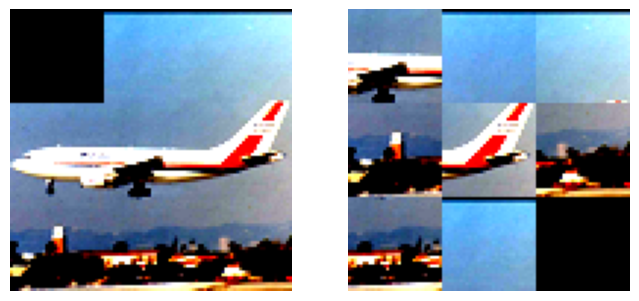

In [2]:
from utils import creation_image
import matplotlib.pyplot as plt 

patch, patch_melange, label = trainset[300]
image = creation_image(patch)
image_melange = creation_image(patch_melange)
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1) 
plt.imshow(image)
plt.axis('off') 

plt.subplot(1, 2, 2) 
plt.imshow(image_melange)
plt.axis('off')

plt.show()

In [14]:
from architecture import PointerNetwork, CNN, GlobalPredictor

patch, patch_melange, label = next(iter(train_loader))
cnn = CNN()
lambdai = cnn(patch_melange)
model = GlobalPredictor()
extracteur = model.predict_order(patch_melange).shape
extracteur

Using cache found in /Users/alexiskerboul/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Using cache found in /Users/alexiskerboul/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


torch.Size([1, 9])

On est bon sur les dimensions

In [5]:
from dataset import DatasetPuzzle
from torch.utils.data import DataLoader
from architecture import GlobalPredictor
from train_architecture import fit
import torch
import numpy as np 
import torch.nn as nn
import torch.optim as optim

BATCH_SIZE = 32
LEARNING_RATE_POINTER = 0.001
LEARNING_RATE_CNN = 0.0001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Lancement de l'entraînement sur : {device}")

trainset = DatasetPuzzle()
testset = DatasetPuzzle(train=False)
train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(testset, batch_size=BATCH_SIZE)

model = GlobalPredictor()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    {'params': model.cnn.parameters(), 'lr': LEARNING_RATE_CNN},      
    {'params': model.pointer.parameters(), 'lr': LEARNING_RATE_POINTER}   
])
n_epoch = 50

train_loss, val_loss, precision = fit(model=model,
                                      criterion=criterion,
                                      optimizer=optimizer,
                                      n_epoch=n_epoch,
                                      train_loader=train_loader,
                                      test_loader=test_loader,
                                      device=device)

Lancement de l'entraînement sur : cpu


Using cache found in /Users/alexiskerboul/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Époque [1/50]:   0%|          | 0/157 [00:00<?, ?it/s]/Users/alexiskerboul/Documents/projet_perso/taquin/architecture.py:19: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  batch_size, num_pieces, colors, hauteur, largeur = X.size()


Époque [1/50]
   Train Loss : 1.4219
   Val Loss   : 44102779.0880 | Précision : 12.12% des pièces bien placées


Époque [2/50]
   Train Loss : 1251770.4694
   Val Loss   : 43887492.0960 | Précision : 12.52% des pièces bien placées


Époque [3/50]
   Train Loss : 2740180.7966
   Val Loss   : 44659697.2480 | Précision : 10.74% des pièces bien placées


Époque [4/50]
   Train Loss : 4684180.2267
   Val Loss   : 44543011.2960 | Précision : 11.07% des pièces bien placées


Époque [5/50]
   Train Loss : 5874021.1698
   Val Loss   : 44649942.2560 | Précision : 11.24% des pièces bien placées


Époque [6/50]
   Train Loss : 5944790.3997
   Val Loss   : 44369369.1040 | Précision : 11.08% des pièces bien placées


Époque [7/50]
   Train Loss : 7247422.0002
   Val Loss   : 44859631.0400 | Précision : 11.07% des pièces bien placées


KeyboardInterrupt: 